# **3.1 Part A: Implementing Convolutional Neural Network from scratch.**

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/5-flower-types-classification-dataset/flower_images/Orchid/489cef8f04.jpg
/kaggle/input/5-flower-types-classification-dataset/flower_images/Orchid/1d043ac951.jpg
/kaggle/input/5-flower-types-classification-dataset/flower_images/Orchid/4587dffd03.jpg
/kaggle/input/5-flower-types-classification-dataset/flower_images/Orchid/9b6ae836b2.jpg
/kaggle/input/5-flower-types-classification-dataset/flower_images/Orchid/a59e4c247e.jpg
/kaggle/input/5-flower-types-classification-dataset/flower_images/Orchid/265024ff3c.jpg
/kaggle/input/5-flower-types-classification-dataset/flower_images/Orchid/2eaca1c694.jpg
/kaggle/input/5-flower-types-classification-dataset/flower_images/Orchid/002c100a56.jpg
/kaggle/input/5-flower-types-classification-dataset/flower_images/Orchid/31a66409b8.jpg
/kaggle/input/5-flower-types-classification-dataset/flower_images/Orchid/d3bac8bbfa.jpg
/kaggle/input/5-flower-types-classification-dataset/flower_images/Orchid/563adfe066.jpg
/kaggle/input/5-flower-types-cla

In [ ]:
base_path = '/kaggle/input/5-flower-types-classification-dataset/flower_images'

In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

output_folder = "/kaggle/working/flower"

splitfolders.ratio(base_path,
                   output=output_folder,
                   seed=1337,
                   ratio=(.7, .15, .15),
                   group_prefix=None)

Copying files: 5000 files [00:19, 262.71 files/s]


In [ ]:
train_dir = '/kaggle/working/flower/train'
val_dir = '/kaggle/working/flower/val'
test_dir = '/kaggle/working/flower/test'

In [ ]:
from PIL import Image
import os
from collections import defaultdict

def check_dataset(folder_path):
    corrupted = []
    class_counts = defaultdict(int)

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                with Image.open(file_path) as img:
                    img.verify()
                # Get class name from folder structure
                class_name = os.path.basename(os.path.dirname(file_path))
                class_counts[class_name] += 1
            except Exception as e:
                corrupted.append(file_path)

    return corrupted, dict(class_counts)

In [ ]:
# Train dataset

train_corrupted, train_distribution = check_dataset(train_dir)

print(f'Dataset has {len(train_corrupted)} corrupted images in train dataset.')

Dataset has 0 corrupted images in train dataset.


In [ ]:
train_distribution

{'Lilly': 700, 'Lotus': 700, 'Sunflower': 700, 'Orchid': 700, 'Tulip': 700}

In [ ]:
# Validation dataset

val_corrupted, val_distribution = check_dataset(val_dir)

print(f'Dataset has {len(val_corrupted)} corrupted images in validation dataset.')

Dataset has 0 corrupted images in validation dataset.


In [ ]:
val_distribution

{'Lilly': 150, 'Lotus': 150, 'Sunflower': 150, 'Orchid': 150, 'Tulip': 150}

In [ ]:
# Test dataset

test_corrupted, test_distribution = check_dataset(test_dir)

print(f'Dataset has {len(test_corrupted)} corrupted images in test dataset.')

Dataset has 0 corrupted images in test dataset.


In [ ]:
test_distribution

{'Lilly': 150, 'Lotus': 150, 'Sunflower': 150, 'Orchid': 150, 'Tulip': 150}

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


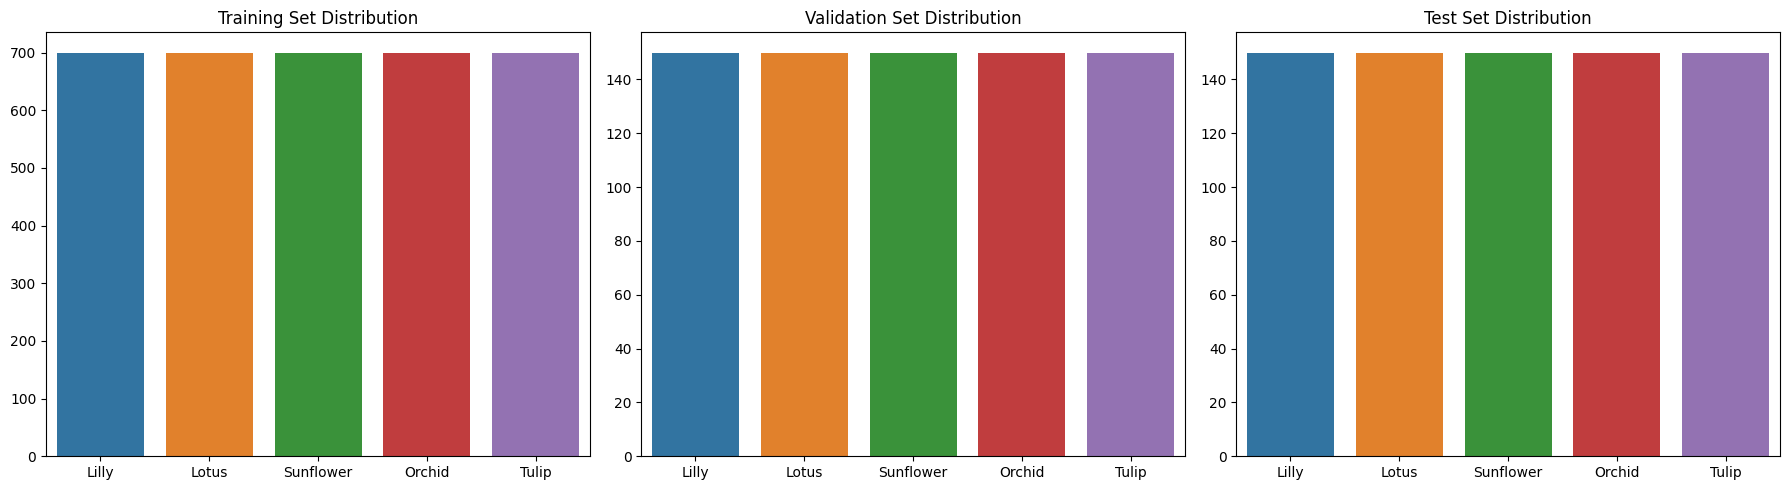

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.barplot(x=list(train_distribution.keys()),
            y=list(train_distribution.values()))
plt.title('Training Set Distribution')

plt.subplot(1, 3, 2)
sns.barplot(x=list(val_distribution.keys()),
            y=list(val_distribution.values()))
plt.title('Validation Set Distribution')

plt.subplot(1, 3, 3)
sns.barplot(x=list(test_distribution.keys()),
            y=list(test_distribution.values()))
plt.title('Test Set Distribution')

plt.tight_layout()
plt.show()

## Load dataset

In [ ]:
image_size = 224

In [ ]:
import tensorflow as tf
from keras.preprocessing import image_dataset_from_directory

train_ds = image_dataset_from_directory(
    train_dir,
    labels='inferred',
    batch_size=32,
    image_size=(image_size, image_size),
    shuffle=True,
    interpolation='nearest',
    verbose=True
)

2025-05-15 07:16:21.270971: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747293381.473068      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747293381.532848      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Found 3499 files belonging to 5 classes.


I0000 00:00:1747293393.288977      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1747293393.289689      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
val_ds = image_dataset_from_directory(
    val_dir,
    labels='inferred',
    batch_size=32,
    image_size=(image_size, image_size),
    interpolation='nearest',
    verbose=True
)

Found 750 files belonging to 5 classes.


In [ ]:
test_ds = image_dataset_from_directory(
    test_dir,
    labels='inferred',
    batch_size=32,
    image_size=(image_size, image_size),
    shuffle=False,
    interpolation='nearest',
    verbose=True
)

Found 750 files belonging to 5 classes.


In [ ]:
class_names = train_ds.class_names

class_names

['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']

## Augmentation Layer

In [ ]:
from keras.layers import (
    RandomFlip, RandomRotation, RandomZoom, RandomContrast,
    RandomTranslation, RandomBrightness, RandomCrop
)
from keras import Sequential

data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.1),
    RandomContrast(0.1),
    RandomTranslation(0.1, 0.1),
    RandomBrightness(0.2),
], name='data_augmentation_layer')

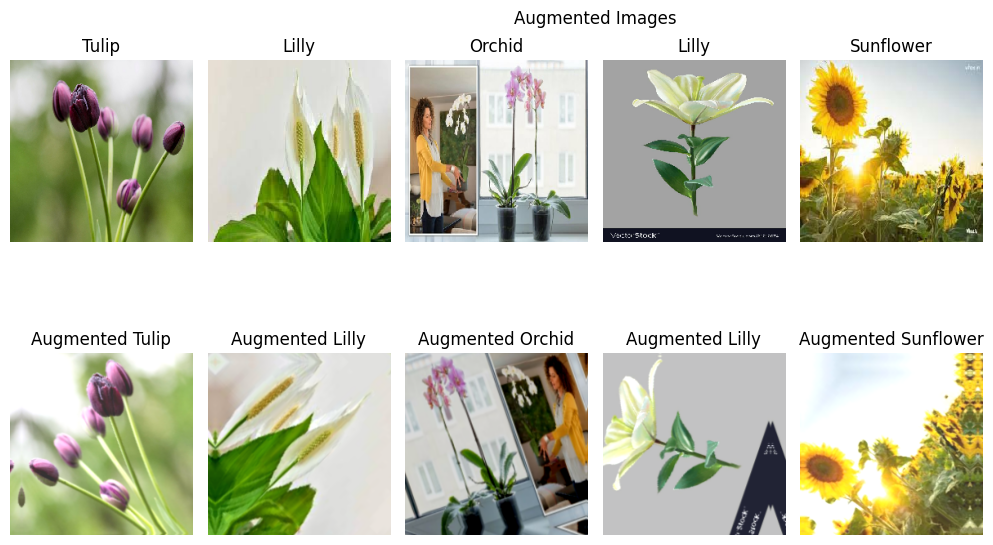

In [ ]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 6))

    for i in range(5):

        ax = plt.subplot(2, 6, i + 1)
        img = images[i].numpy()
        plt.imshow(img.astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

        ax = plt.subplot(2, 6, i + 7)
        augmented_img = data_augmentation(images[i:i+1])
        augmented_img = augmented_img.numpy()
        plt.imshow(augmented_img[0].astype("uint8"))
        plt.title("Augmented " + class_names[labels[i]])
        plt.axis("off")

    plt.tight_layout()
    plt.suptitle("Augmented Images")
    plt.show()


# **1.2 Design, Train, and Evaluate a Baseline Model**

In [ ]:
from keras.layers import (
        Conv2D, Rescaling, Dense,
        MaxPooling2D, Input, Flatten,
        BatchNormalization, Dropout, GlobalAveragePooling2D)

model1 = Sequential([

    Input(shape=(image_size, image_size, 3)),
    data_augmentation,

    Rescaling(1./255),

    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),

    Conv2D(96, (3,3), activation="relu"),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(96, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(5, activation="softmax")
])

In [ ]:
model1.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
                        monitor='val_loss',
                        patience=5,
                        restore_best_weights=True
                    )

In [ ]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation_layer (Sequential) │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 96)          │          55,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 96)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 64896)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 96)                  │       6,230,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,313,349 (24.08 MB)

 Trainable params: 6,313,349 (24.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time

model1_start_time = time.time()

model_history = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks = [early_stopping]
)

model1_end_time = time.time()

Epoch 1/40


I0000 00:00:1747293403.500716     114 cuda_dnn.cc:529] Loaded cuDNN version 90300


110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step - accuracy: 0.3337 - loss: 1.4979 - val_accuracy: 0.5107 - val_loss: 1.2109
Epoch 2/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.5225 - loss: 1.1748 - val_accuracy: 0.5747 - val_loss: 1.0958
Epoch 3/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.5610 - loss: 1.0890 - val_accuracy: 0.5653 - val_loss: 1.0474
Epoch 4/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.5836 - loss: 1.0503 - val_accuracy: 0.5733 - val_loss: 1.0524
Epoch 5/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.6157 - loss: 0.9877 - val_accuracy: 0.6213 - val_loss: 0.9804
Epoch 6/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.5975 - loss: 1.0069 - val_accuracy: 0.6560 - val_loss: 0.9438
Epoch 7/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.6341 - loss: 0.9496 - val_accuracy: 0.5800 - val_loss: 1.0481
Epoch 8/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.6389 - loss: 0.9255 - val_accuracy: 0.64

In [ ]:
model1_time = model1_end_time - model1_start_time
print(f"\nBaseline Model Training took {model1_time:.2f} seconds.")


Baseline Model Training took 247.96 seconds.


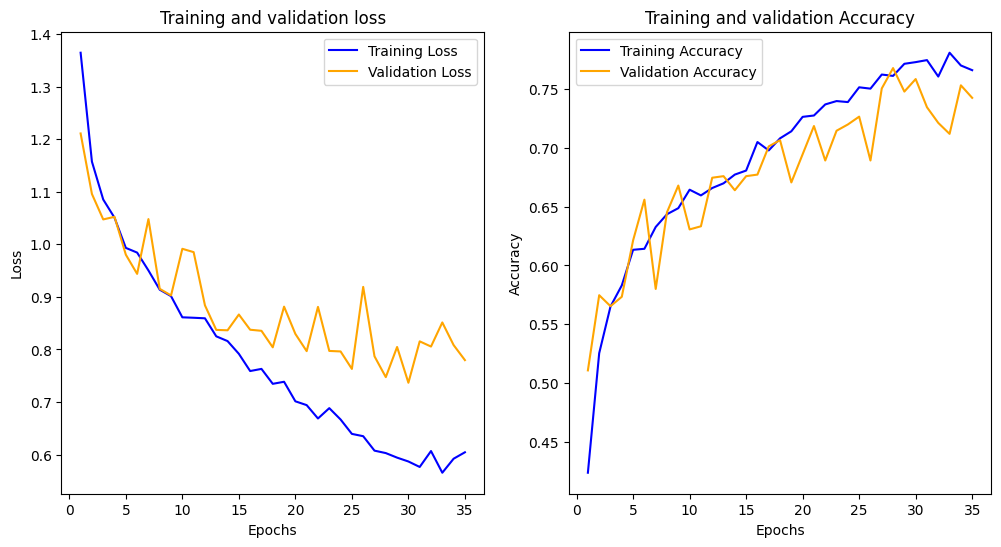

In [ ]:
train_loss =(model_history.history['loss'])
validation_loss =(model_history.history['val_loss'])
train_accuracy = (model_history.history['accuracy'])
validation_accuracy =(model_history.history['val_accuracy'])

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label = 'Training Loss', color = 'blue')
plt.plot(range(1, len(validation_loss) + 1), validation_loss, label = 'Validation Loss', color = 'orange')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title('Training and validation loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(1, len(train_accuracy) + 1), train_accuracy, label = 'Training Accuracy', color = 'blue')
plt.plot(range(1, len(validation_accuracy) + 1), validation_accuracy, label = 'Validation Accuracy', color = 'orange')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title('Training and validation Accuracy')
plt.legend()

In [ ]:
import numpy as np

# convert the actural labels to the numpy array
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

In [ ]:
from sklearn.metrics import classification_report

model1_prediction = model1.predict(test_ds)
y_pred = np.argmax(model1_prediction, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
              precision    recall  f1-score   support

       Lilly       0.56      0.70      0.62       150
       Lotus       0.81      0.71      0.75       150
      Orchid       0.77      0.57      0.66       150
   Sunflower       0.88      0.95      0.91       150
       Tulip       0.73      0.77      0.75       150

    accuracy                           0.74       750
   macro avg       0.75      0.74      0.74       750
weighted avg       0.75      0.74      0.74       750



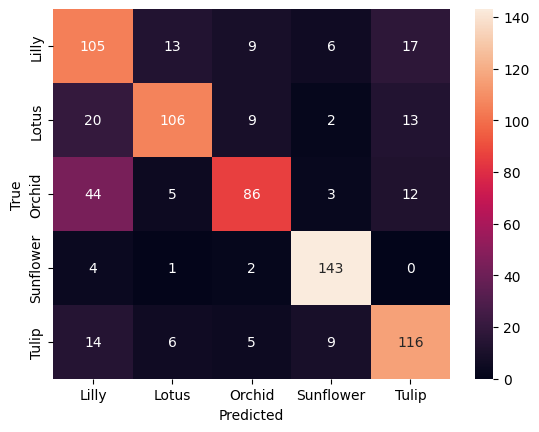

In [ ]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step


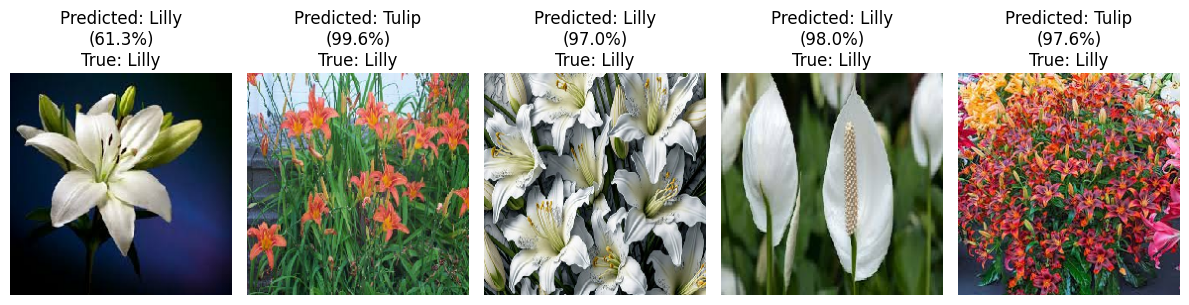

In [ ]:
for images, labels in test_ds.take(1):
    predictions = model1.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    plt.figure(figsize=(12, 6))
    for i in range(5):
        ax = plt.subplot(1, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class = class_names[predicted_labels[i]]
        true_class = class_names[labels[i]]
        confidence = 100 * np.max(predictions[i])

        plt.title(f"Predicted: {predicted_class}\n({confidence:.1f}%)\nTrue: {true_class}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# **1.3 Design, Train , and Evaluate Deeper Architecture with Regularization Layer**

In [ ]:
from keras import regularizers
from keras.layers import Conv2D, Rescaling, Dense, MaxPooling2D, Input, Flatten, BatchNormalization, Dropout, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model2 = Sequential([

    Input(shape=(image_size, image_size, 3)),
    data_augmentation,

    Rescaling(1./255),

    Conv2D(16, (3, 3), activation='relu', kernel_regularizer=l2(0.001), padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001), padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001), padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001), padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.001), padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    GlobalAveragePooling2D(),

    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(5, activation='softmax')
])

In [ ]:
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                            factor=0.2,
                            patience=2,
                            cooldown=1,
                            min_lr=1e-6)

In [ ]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation_layer (Sequential) │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_1 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 224, 224, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 112, 112, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 112, 112, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 56, 56, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 56, 56, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 14, 14, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 428,133 (1.63 MB)

 Trainable params: 427,141 (1.63 MB)

 Non-trainable params: 992 (3.88 KB)

In [ ]:
import time

model2_start_time = time.time()

model2_history = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks = [early_stopping, reduce_lr]
)

model2_end_time = time.time()

Epoch 1/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - accuracy: 0.4412 - loss: 1.9598 - val_accuracy: 0.2440 - val_loss: 2.2048 - learning_rate: 0.0010
Epoch 2/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.5512 - loss: 1.6234 - val_accuracy: 0.2787 - val_loss: 2.4870 - learning_rate: 0.0010
Epoch 3/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.5686 - loss: 1.5435 - val_accuracy: 0.4813 - val_loss: 1.6975 - learning_rate: 0.0010
Epoch 4/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.5896 - loss: 1.4623 - val_accuracy: 0.4173 - val_loss: 1.7524 - learning_rate: 0.0010
Epoch 5/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.5857 - loss: 1.4011 - val_accuracy: 0.5800 - val_loss: 1.3882 - learning_rate: 0.0010
Epoch 6/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.6173 - loss: 1.3389 - val_accuracy: 0.6000 - val_loss: 1.3379 - learning_rate: 0.0010
Epoch 7/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - accuracy: 0.6231 - l

In [ ]:
model2_time = model2_end_time - model2_start_time
print(f"\nBaseline Model Training took {model2_time:.2f} seconds.")


Baseline Model Training took 392.86 seconds.


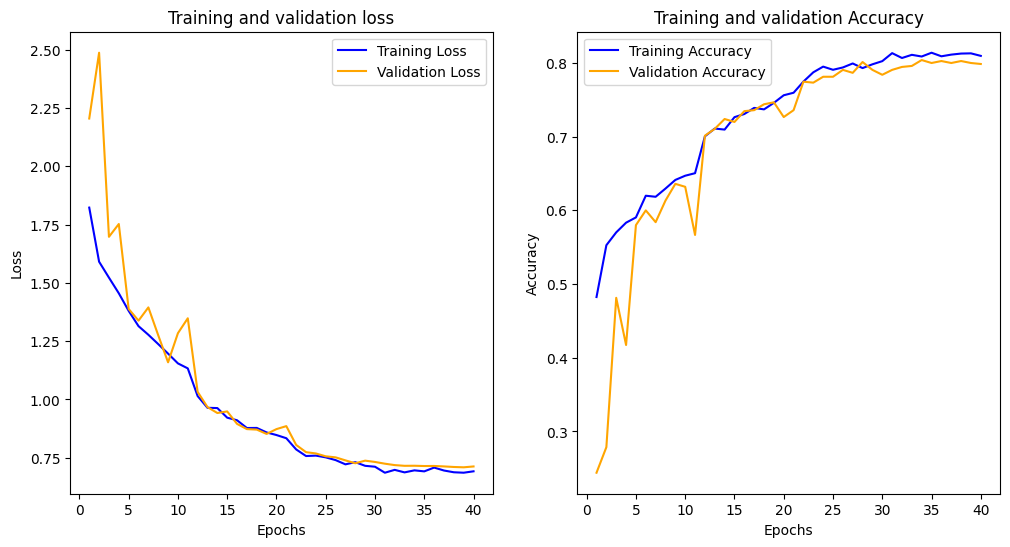

In [ ]:
train_loss =(model2_history.history['loss'])
validation_loss =(model2_history.history['val_loss'])
train_accuracy = (model2_history.history['accuracy'])
validation_accuracy =(model2_history.history['val_accuracy'])

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label = 'Training Loss', color = 'blue')
plt.plot(range(1, len(validation_loss) + 1), validation_loss, label = 'Validation Loss', color = 'orange')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title('Training and validation loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(1, len(train_accuracy) + 1), train_accuracy, label = 'Training Accuracy', color = 'blue')
plt.plot(range(1, len(validation_accuracy) + 1), validation_accuracy, label = 'Validation Accuracy', color = 'orange')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title('Training and validation Accuracy')
plt.legend()

In [ ]:
y_labels = model2.predict(test_ds)
y_pred = np.argmax(y_labels, axis=1)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       Lilly       0.62      0.74      0.68       150
       Lotus       0.76      0.82      0.79       150
      Orchid       0.84      0.69      0.76       150
   Sunflower       0.95      0.95      0.95       150
       Tulip       0.86      0.78      0.82       150

    accuracy                           0.80       750
   macro avg       0.81      0.80      0.80       750
weighted avg       0.81      0.80      0.80       750



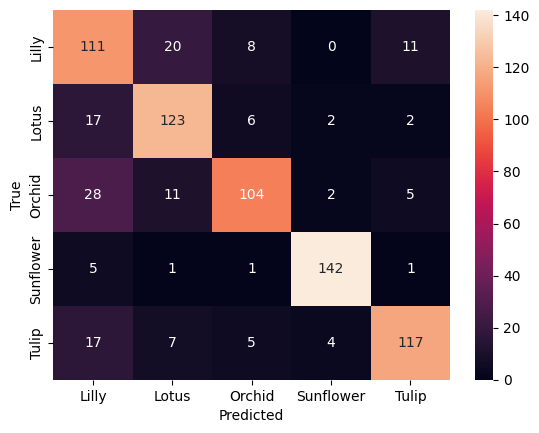

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step


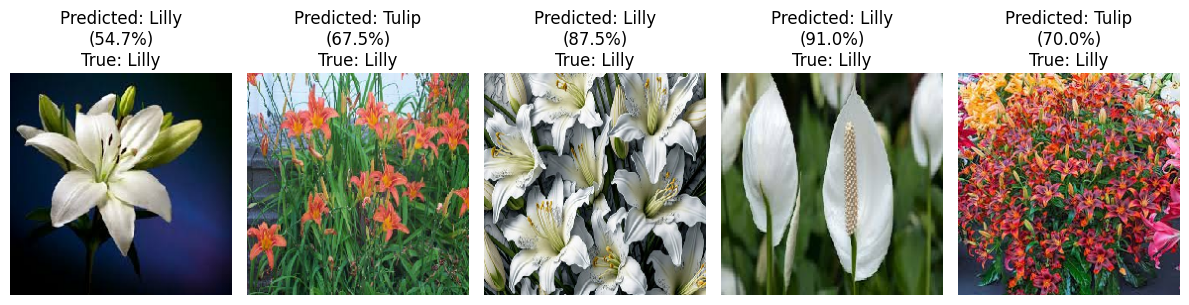

In [ ]:
for images, labels in test_ds.take(1):
    predictions = model2.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    plt.figure(figsize=(12, 6))
    for i in range(5):
        ax = plt.subplot(1, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class = class_names[predicted_labels[i]]
        true_class = class_names[labels[i]]
        confidence = 100 * np.max(predictions[i])

        plt.title(f"Predicted: {predicted_class}\n({confidence:.1f}%)\nTrue: {true_class}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# **1.4 Experimentation and Comparative Analysis**

### **Optimizer Analysis: SGD vs Adam**

In [ ]:
from keras import regularizers
from keras.layers import (
        Conv2D, Rescaling, Dense,
        MaxPooling2D, Input, Flatten,
        BatchNormalization, Dropout, GlobalAveragePooling2D)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model_sgd = Sequential([

    Input(shape=(image_size, image_size, 3)),
    data_augmentation,

    Rescaling(1./255),

    Conv2D(16, (3, 3), activation='relu', kernel_regularizer=l2(0.001), padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001), padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001), padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001), padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.001), padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    GlobalAveragePooling2D(),

    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(5, activation='softmax')
])

In [ ]:
model_sgd.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model_sgd.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation_layer (Sequential) │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_2 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 224, 224, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 224, 224, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 112, 112, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 112, 112, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 112, 112, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 56, 56, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 56, 56, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 56, 56, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 14, 14, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 428,133 (1.63 MB)

 Trainable params: 427,141 (1.63 MB)

 Non-trainable params: 992 (3.88 KB)

In [ ]:

model_sgd_start_time = time.time()

model_sgd_history = model_sgd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks = [early_stopping, reduce_lr]
)

model_sgd_end_time = time.time()

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - accuracy: 0.4155 - loss: 1.9780 - val_accuracy: 0.2147 - val_loss: 2.1164 - learning_rate: 0.0100
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.5402 - loss: 1.6529 - val_accuracy: 0.3133 - val_loss: 1.9518 - learning_rate: 0.0100
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.5664 - loss: 1.5739 - val_accuracy: 0.4720 - val_loss: 1.7254 - learning_rate: 0.0100
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.6110 - loss: 1.5157 - val_accuracy: 0.5640 - val_loss: 1.5940 - learning_rate: 0.0100
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.6034 - loss: 1.5050 - val_accuracy: 0.6333 - val_loss: 1.4699 - learning_rate: 0.0100
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.6122 - loss: 1.4781 - val_accuracy: 0.5813 - val_loss: 1.5427 - learning_rate: 0.0100
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.6219 - loss: 

In [ ]:
model_sgd_time = model_sgd_end_time - model_sgd_start_time
print(f"\nBaseline Model Training took {model_sgd_time:.2f} seconds.")


Baseline Model Training took 190.95 seconds.


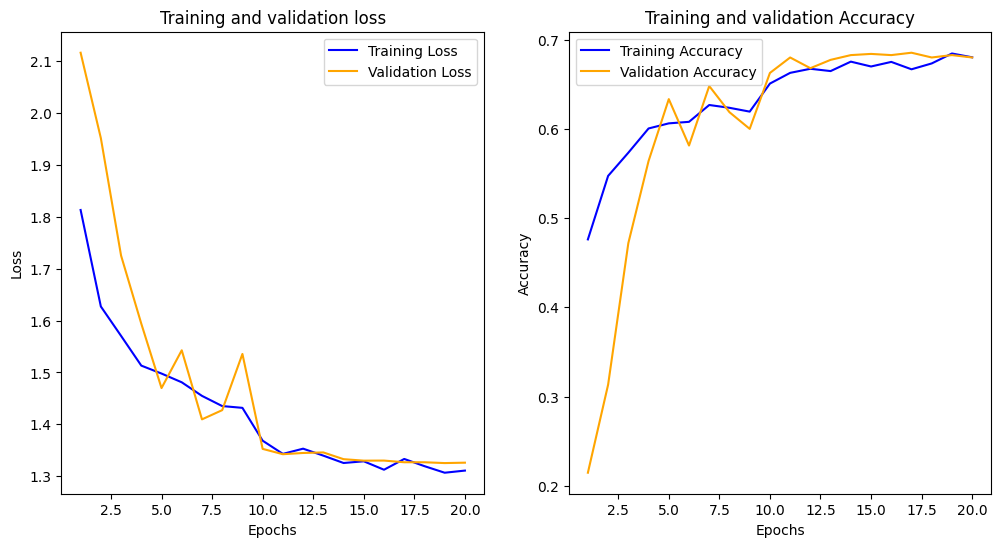

In [ ]:
train_loss =(model_sgd_history.history['loss'])
validation_loss =(model_sgd_history.history['val_loss'])
train_accuracy = (model_sgd_history.history['accuracy'])
validation_accuracy =(model_sgd_history.history['val_accuracy'])

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label = 'Training Loss', color = 'blue')
plt.plot(range(1, len(validation_loss) + 1), validation_loss, label = 'Validation Loss', color = 'orange')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title('Training and validation loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(1, len(train_accuracy) + 1), train_accuracy, label = 'Training Accuracy', color = 'blue')
plt.plot(range(1, len(validation_accuracy) + 1), validation_accuracy, label = 'Validation Accuracy', color = 'orange')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title('Training and validation Accuracy')
plt.legend()

In [ ]:
y_labels = model_sgd.predict(test_ds)
y_pred = np.argmax(y_labels, axis=1)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       Lilly       0.54      0.65      0.59       150
       Lotus       0.77      0.65      0.70       150
      Orchid       0.66      0.69      0.68       150
   Sunflower       0.84      0.95      0.89       150
       Tulip       0.76      0.59      0.67       150

    accuracy                           0.71       750
   macro avg       0.71      0.71      0.70       750
weighted avg       0.71      0.71      0.70       750



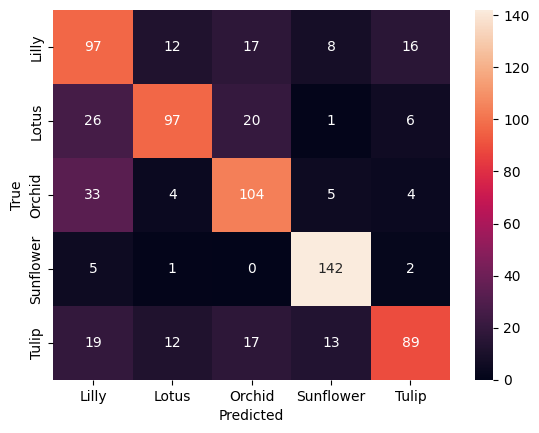

In [ ]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
model_adam = Sequential([

    Input(shape=(image_size, image_size, 3)),
    data_augmentation,

    Rescaling(1./255),

    Conv2D(16, (3, 3), activation='relu', kernel_regularizer=l2(0.001), padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001), padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001), padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001), padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.001), padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    GlobalAveragePooling2D(),

    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(5, activation='softmax')
])

In [ ]:
model_adam.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping


model_adam_start = time.time()

model_adam_history = model_adam.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks = [early_stopping, reduce_lr]
)

model_adam_end = time.time()

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.4513 - loss: 1.9301 - val_accuracy: 0.2293 - val_loss: 2.1959 - learning_rate: 0.0010
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.5412 - loss: 1.6434 - val_accuracy: 0.2173 - val_loss: 2.4707 - learning_rate: 0.0010
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.5544 - loss: 1.5254 - val_accuracy: 0.2693 - val_loss: 2.7977 - learning_rate: 0.0010
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.6109 - loss: 1.4235 - val_accuracy: 0.4560 - val_loss: 1.7706 - learning_rate: 2.0000e-04
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.6386 - loss: 1.3448 - val_accuracy: 0.6213 - val_loss: 1.3589 - learning_rate: 2.0000e-04
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - accuracy: 0.6470 - loss: 1.3042 - val_accuracy: 0.6693 - val_loss: 1.3026 - learning_rate: 2.0000e-04
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy:

In [ ]:
model_adam_time = model_adam_end - model_adam_start
print(f"\nBaseline Model Training took {model_adam_time:.2f} seconds.")


Baseline Model Training took 199.71 seconds.


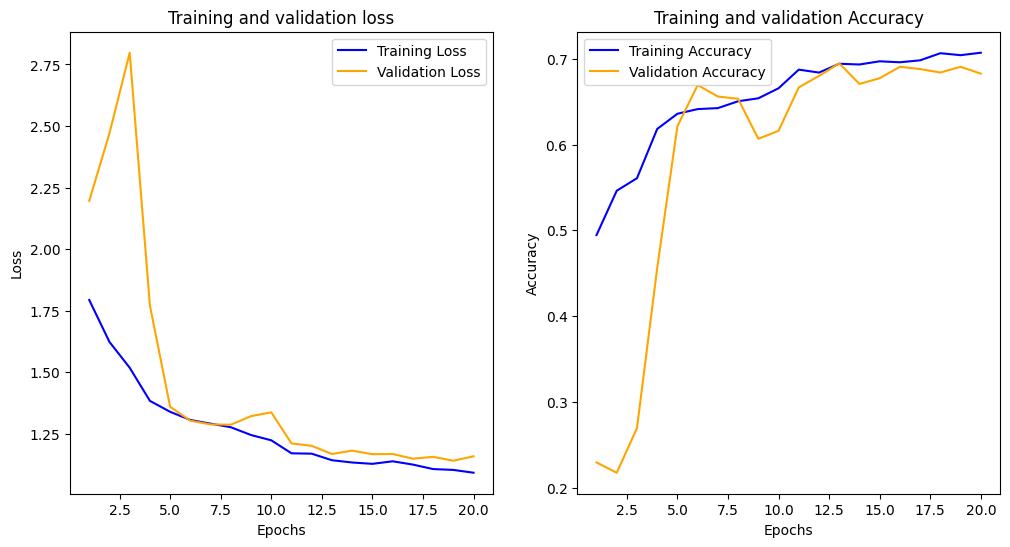

In [ ]:
train_loss =(model_adam_history.history['loss'])
validation_loss =(model_adam_history.history['val_loss'])
train_accuracy = (model_adam_history.history['accuracy'])
validation_accuracy =(model_adam_history.history['val_accuracy'])

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label = 'Training Loss', color = 'blue')
plt.plot(range(1, len(validation_loss) + 1), validation_loss, label = 'Validation Loss', color = 'orange')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title('Training and validation loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(1, len(train_accuracy) + 1), train_accuracy, label = 'Training Accuracy', color = 'blue')
plt.plot(range(1, len(validation_accuracy) + 1), validation_accuracy, label = 'Validation Accuracy', color = 'orange')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title('Training and validation Accuracy')
plt.legend()

# **Comparision of Baseline Model and Regularized Model**

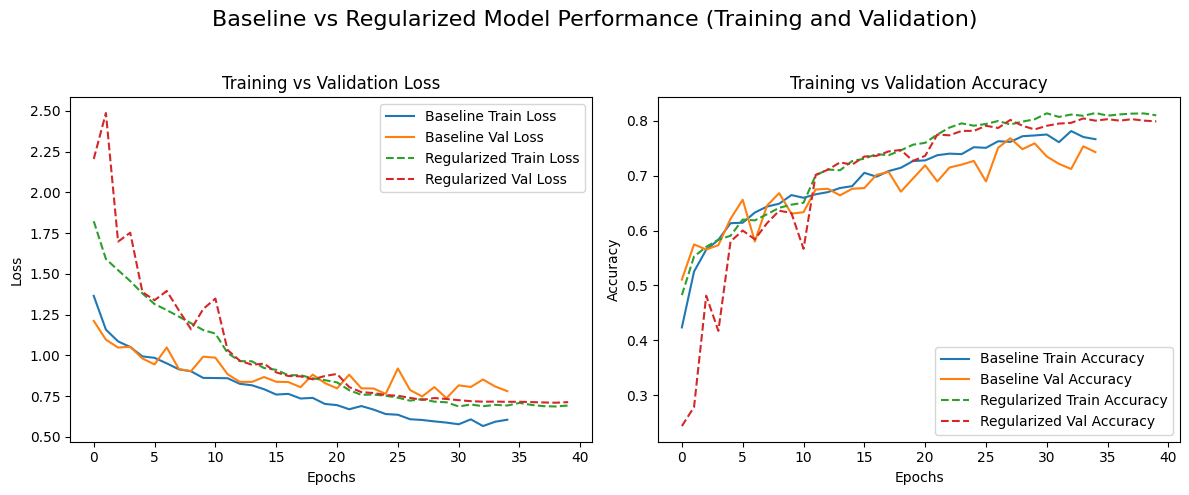

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model_history.history['loss'],
         label='Baseline Train Loss')
plt.plot(model_history.history['val_loss'],
         label='Baseline Val Loss')

plt.plot(model2_history.history['loss'],
         label='Regularized Train Loss',
         linestyle='--')

plt.plot(model2_history.history['val_loss'],
         label='Regularized Val Loss',
         linestyle='--')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(model_history.history['accuracy'], label='Baseline Train Accuracy')
plt.plot(model_history.history['val_accuracy'], label='Baseline Val Accuracy')
plt.plot(model2_history.history['accuracy'], label='Regularized Train Accuracy', linestyle='--')
plt.plot(model2_history.history['val_accuracy'], label='Regularized Val Accuracy', linestyle='--')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.suptitle('Baseline vs Regularized Model Performance (Training and Validation)', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('model_comparison_train_val.png')
plt.show()

# **Comparision of SGD vs Adam**

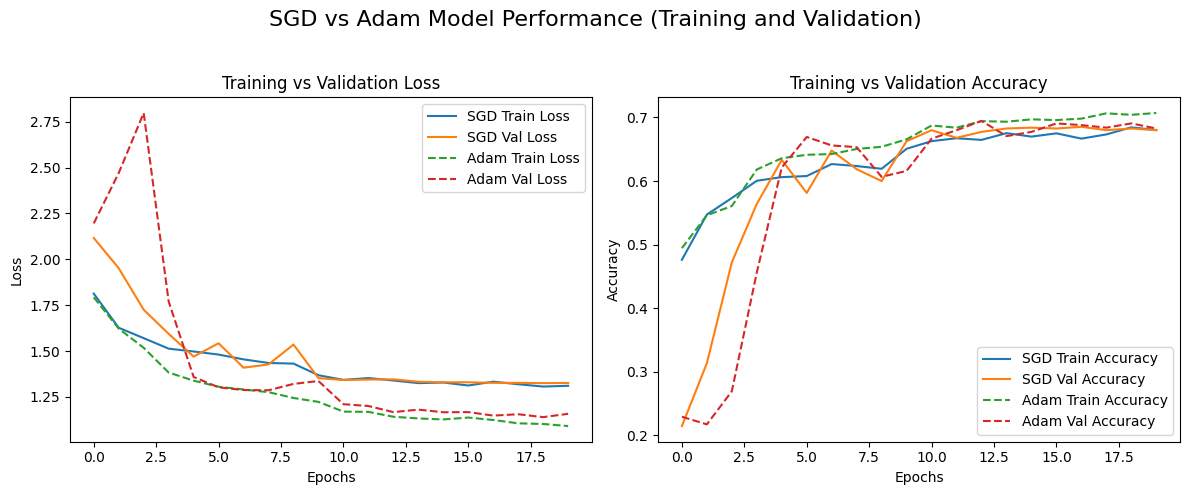

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model_sgd_history.history['loss'],
         label='SGD Train Loss')
plt.plot(model_sgd_history.history['val_loss'],
         label='SGD Val Loss')

plt.plot(model_adam_history.history['loss'],
         label='Adam Train Loss',
         linestyle='--')

plt.plot(model_adam_history.history['val_loss'],
         label='Adam Val Loss',
         linestyle='--')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(model_sgd_history.history['accuracy'],
         label='SGD Train Accuracy')
plt.plot(model_sgd_history.history['val_accuracy'],
         label='SGD Val Accuracy')
plt.plot(model_adam_history.history['accuracy'],
         label='Adam Train Accuracy',
         linestyle='--')
plt.plot(model_adam_history.history['val_accuracy'],
         label='Adam Val Accuracy',
         linestyle='--')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.suptitle('SGD vs Adam Model Performance (Training and Validation)', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('model_comparison_train_val.png')
plt.show()

# **Fine-Tuning a Pre-Trained Model (Transfer Learning)**

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Load VGG16 with pre-trained ImageNet weights, excluding top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the convolutional base
base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Add custom layers for classification
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Reduce spatial dimensions
x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)  # Dense layer with L2 regularization
x = BatchNormalization()(x)  # Consistent with Part A
x = Dropout(0.5)(x)  # Prevent overfitting
predictions = Dense(5, activation='softmax')(x)  # 5-class output

In [ ]:
# Create the final model
transfer_model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
transfer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',  # For one-hot encoded labels
    metrics=['accuracy']
)

In [ ]:
transfer_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 512)                 │         262,6

 Total params: 14,981,957 (57.15 MB)

 Trainable params: 266,245 (1.02 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [ ]:
base_model.trainable = False

In [ ]:
# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(5, activation='softmax')(x)

In [ ]:
# Create the final model
transfer_model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
transfer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
transfer_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 512)                 │         262,6

 Total params: 14,981,957 (57.15 MB)

 Trainable params: 266,245 (1.02 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [ ]:
transfer_layer_history = transfer_model.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/15


I0000 00:00:1747294444.408010     116 service.cc:148] XLA service 0x7c1bb800a940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747294444.408725     116 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1747294444.408741     116 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1747294460.693240     116 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


110/110 ━━━━━━━━━━━━━━━━━━━━ 69s 464ms/step - accuracy: 0.5877 - loss: 1.8134 - val_accuracy: 0.8333 - val_loss: 1.0620 - learning_rate: 0.0010
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 30s 277ms/step - accuracy: 0.8298 - loss: 0.9606 - val_accuracy: 0.8547 - val_loss: 0.9473 - learning_rate: 0.0010
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 31s 283ms/step - accuracy: 0.8823 - loss: 0.7939 - val_accuracy: 0.8720 - val_loss: 0.8653 - learning_rate: 0.0010
Epoch 4/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 31s 278ms/step - accuracy: 0.8937 - loss: 0.7209 - val_accuracy: 0.8853 - val_loss: 0.7760 - learning_rate: 0.0010
Epoch 5/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 31s 277ms/step - accuracy: 0.9135 - loss: 0.6543 - val_accuracy: 0.8973 - val_loss: 0.7569 - learning_rate: 0.0010
Epoch 6/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 31s 282ms/step - accuracy: 0.9144 - loss: 0.6333 - val_accuracy: 0.8987 - val_loss: 0.6991 - learning_rate: 0.0010
Epoch 7/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 31s 282ms/step - accuracy: 0.9256 - loss:

In [ ]:
# Fine-Tuning
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 4

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [ ]:
# Recompile
transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Fine-tune
transfer_layer_history_fine = transfer_model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 46s 349ms/step - accuracy: 0.8638 - loss: 0.6892 - val_accuracy: 0.4813 - val_loss: 4.6803 - learning_rate: 1.0000e-04
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 34s 313ms/step - accuracy: 0.8425 - loss: 0.6741 - val_accuracy: 0.5547 - val_loss: 3.1743 - learning_rate: 1.0000e-04
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 34s 312ms/step - accuracy: 0.8463 - loss: 0.6481 - val_accuracy: 0.8613 - val_loss: 0.7183 - learning_rate: 1.0000e-04
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 34s 311ms/step - accuracy: 0.9265 - loss: 0.4165 - val_accuracy: 0.8707 - val_loss: 0.7161 - learning_rate: 1.0000e-04
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 34s 311ms/step - accuracy: 0.9560 - loss: 0.3401 - val_accuracy: 0.9373 - val_loss: 0.4666 - learning_rate: 1.0000e-04
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 34s 312ms/step - accuracy: 0.9667 - loss: 0.2966 - val_accuracy: 0.9427 - val_loss: 0.4061 - learning_rate: 1.0000e-04
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 34s 31

In [ ]:
test_loss, test_accuracy = transfer_model.evaluate(test_ds)
print(f"Transfer Learning - Test Accuracy: {test_accuracy:.4f}")
print(f"Transfer Learning - Test Loss: {test_loss:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 227ms/step - accuracy: 0.9332 - loss: 0.4623
Transfer Learning - Test Accuracy: 0.9507
Transfer Learning - Test Loss: 0.3560


In [ ]:
y_labels = transfer_model.predict(test_ds)
y_pred = np.argmax(y_labels, axis=1)

24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 233ms/step


In [ ]:
print("\nClassification Report (Transfer Learning):")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report (Transfer Learning):
              precision    recall  f1-score   support

       Lilly       0.91      0.93      0.92       150
       Lotus       0.92      0.94      0.93       150
      Orchid       0.98      0.94      0.96       150
   Sunflower       0.97      0.98      0.97       150
       Tulip       0.98      0.97      0.97       150

    accuracy                           0.95       750
   macro avg       0.95      0.95      0.95       750
weighted avg       0.95      0.95      0.95       750



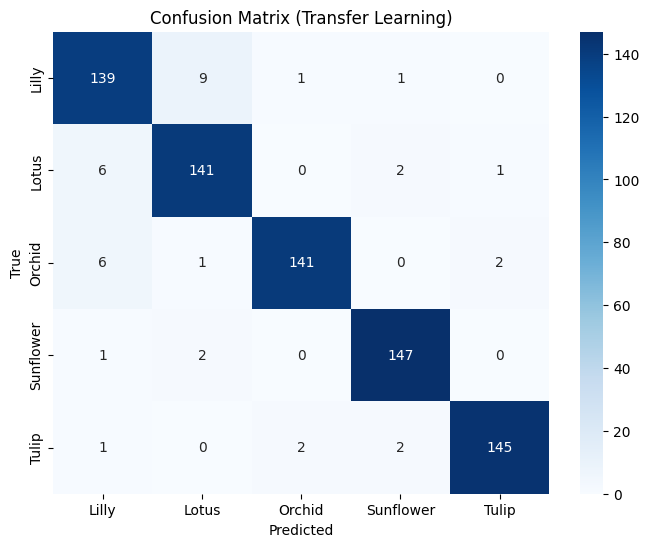

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Transfer Learning)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step


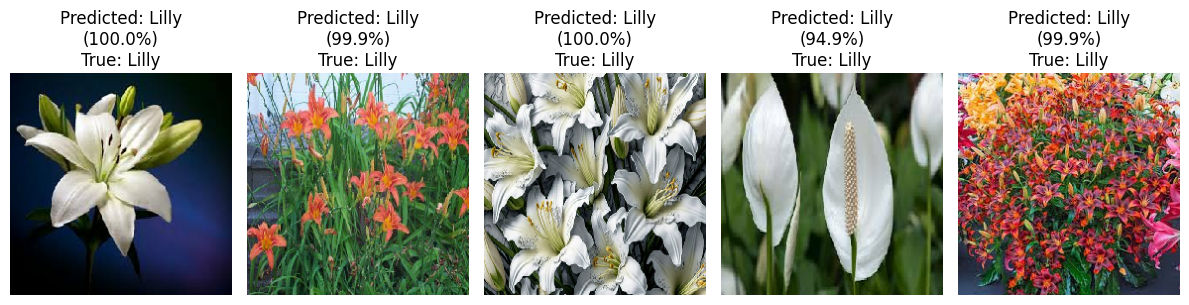

In [ ]:
for images, labels in test_ds.take(1):
    predictions = transfer_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    plt.figure(figsize=(12, 6))
    for i in range(5):
        ax = plt.subplot(1, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class = class_names[predicted_labels[i]]
        true_class = class_names[labels[i]]
        confidence = 100 * np.max(predictions[i])

        plt.title(f"Predicted: {predicted_class}\n({confidence:.1f}%)\nTrue: {true_class}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

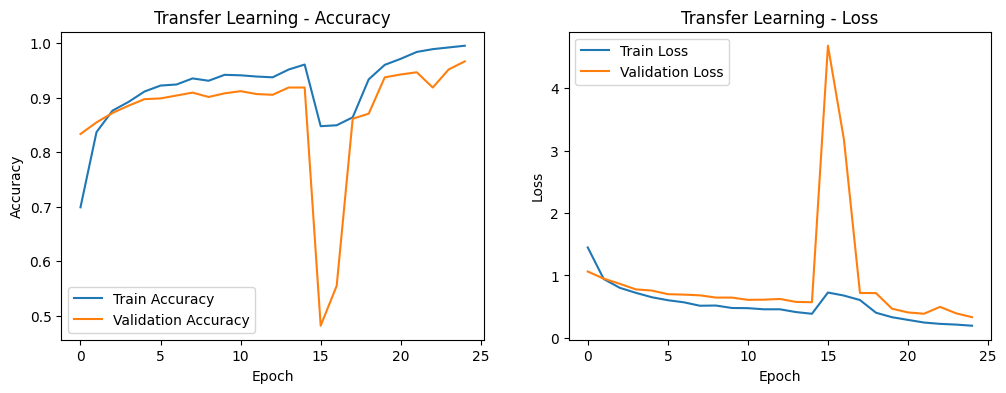

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(transfer_layer_history.history['accuracy'] + transfer_layer_history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(transfer_layer_history.history['val_accuracy'] + transfer_layer_history_fine.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(transfer_layer_history.history['loss'] + transfer_layer_history_fine.history['loss'], label='Train Loss')
plt.plot(transfer_layer_history.history['val_loss'] + transfer_layer_history_fine.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()